# EDA Train_transaction

## Train_transaction

In [1]:
# -----------------------------------------------------------
# 1. Paquetes necesarios para el análisis
# -----------------------------------------------------------

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency, ttest_ind

In [2]:
# -----------------------------------------------------------------------
# 2. Cargar los datos de train_transaction desde nuestro disco duro local
#    cambia la ruta a la ubicación de tu archivo CSV
# -----------------------------------------------------------------------

train_transaction = pd.read_csv(r"C:/Users/jthow/iCloudDrive/Documents/3_Maestria_Estadistica_UNINORTE/3_Tercer_Semestre/Machine_Learning/Parcial_Practico/fraude/train_transaction.csv")

# -----------------------------------------------------------------------
# 3. Inspeccionar los datos cargados
# -----------------------------------------------------------------------

train_transaction

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.50,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.00,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.00,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.00,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.00,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,3577535,0,15811047,49.00,W,6550,NaN,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590536,3577536,0,15811049,39.50,W,10444,225.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590537,3577537,0,15811079,30.95,W,12037,595.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590538,3577538,0,15811088,117.00,W,7826,481.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


TRAIN TRANSACTION

Estructura de la Base de Datos
Filas y Columnas:

La base de datos contiene 590,540 filas y 394 columnas. Esto indica un conjunto de datos bastante grande y complejo.
Columnas Principales:

TransactionID: Un identificador único para cada transacción. Es crucial para rastrear y referenciar transacciones individuales.
isFraud: Una variable binaria que indica si la transacción es fraudulenta (1) o no (0). Esta es la variable objetivo para modelos de detección de fraudes.
TransactionDT: La fecha y hora de la transacción, representada como un número entero. Este campo es esencial para el análisis temporal.
TransactionAmt: El monto de la transacción. Es una variable continua que puede ser útil para análisis financieros y detección de fraudes.
ProductCD: Un código que representa el tipo de producto involucrado en la transacción. Puede ser categórico y útil para segmentar los datos por tipo de producto.
card1 a card6: Información relacionada con la tarjeta utilizada en la transacción. Estos campos pueden incluir detalles como el número de tarjeta (posiblemente encriptado), el tipo de tarjeta, el emisor, etc.
V330 a V339: Estas columnas parecen ser variables adicionales, posiblemente características anonimizadas o codificadas. Los valores NaN indican que estas columnas pueden tener datos faltantes o no aplicables para ciertas transacciones.

In [3]:
# -----------------------------------------------------------------------
# 4. Cargar los datos de train_identity desde nuestro disco duro local
#    cambia la ruta a la ubicación de tu archivo CSV
# -----------------------------------------------------------------------

train_identity = pd.read_csv(r"C:/Users/jthow/iCloudDrive/Documents/3_Maestria_Estadistica_UNINORTE/3_Tercer_Semestre/Machine_Learning/Parcial_Practico/fraude/train_identity.csv")

# -----------------------------------------------------------------------
# 5. Inspeccionar los datos cargados
# -----------------------------------------------------------------------

train_identity

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144228,3577521,-15.0,145955.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 66.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,F3111 Build/33.3.A.1.97
144229,3577526,-5.0,172059.0,NaN,NaN,1.0,-5.0,NaN,NaN,NaN,...,chrome 55.0 for android,32.0,855x480,match_status:2,T,F,T,F,mobile,A574BL Build/NMF26F
144230,3577529,-20.0,632381.0,NaN,NaN,-1.0,-36.0,NaN,NaN,NaN,...,chrome 65.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,Moto E (4) Plus Build/NMA26.42-152
144231,3577531,-5.0,55528.0,0.0,0.0,0.0,-7.0,NaN,NaN,0.0,...,chrome 66.0,24.0,2560x1600,match_status:2,T,F,T,F,desktop,MacOS


La tabla presentada contiene 144,233 filas y 41 columnas, proporcionando una visión detallada de diversas características de las transacciones. Cada fila representa una transacción única identificada por `TransactionID`, con columnas adicionales que incluyen identificadores numéricos (`id_01` a `id_38`), tipo de dispositivo (`DeviceType`) y información específica del dispositivo (`DeviceInfo`). Los identificadores numéricos muestran una variedad de valores, incluyendo algunos faltantes (`NaN`), lo que sugiere la necesidad de manejo de datos faltantes. El tipo de dispositivo indica si la transacción se realizó desde un dispositivo móvil o de escritorio, mientras que `DeviceInfo` proporciona detalles adicionales como el modelo y el sistema operativo del dispositivo. En conjunto, esta tabla ofrece una rica fuente de información para el análisis transaccional, destacando la diversidad de dispositivos y sistemas operativos utilizados, así como la presencia de datos faltantes que deben ser considerados en cualquier análisis posterior.

In [4]:
# -----------------------------------------------------------------------
# 7. Paquetes necesarios para medir el tiempo de ejecución
# -----------------------------------------------------------------------

import time
import pandas as pd

# Lista para almacenar los tiempos de ejecución
execution_times = []

#-------------------------------------------------------------------------
# 8. Fusionar los dos conjuntos de datos train_transaction y train_identity en uno solo para redefinir FD_train
#-------------------------------------------------------------------------

start_time = time.time()  # Iniciar el cronómetro

FD_train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')

end_time = time.time()  # Detener el cronómetro
elapsed_time = end_time - start_time
execution_times.append(("Fusión de DataFrames", elapsed_time))

#-------------------------------------------------------------------------
# 7. Guardar el DataFrame fusionado en un archivo CSV en la ruta especificada
#-------------------------------------------------------------------------

start_time = time.time()  # Iniciar el cronómetro

FD_train.to_csv("C:/Users/jthow/iCloudDrive/Documents/3_Maestria_Estadistica_UNINORTE/3_Tercer_Semestre/Machine_Learning/Parcial_Practico/FD_train.csv", index=False)

end_time = time.time()  # Detener el cronómetro
elapsed_time = end_time - start_time
execution_times.append(("Guardado del CSV", elapsed_time))

#-------------------------------------------------------------------------
# 8. Inspeccionar los datos fusionados
#-------------------------------------------------------------------------

start_time = time.time()  # Iniciar el cronómetro

print(FD_train.head())  # Muestra las primeras filas del DataFrame

end_time = time.time()  # Detener el cronómetro
elapsed_time = end_time - start_time
execution_times.append(("Inspección de datos", elapsed_time))

#-------------------------------------------------------------------------
# 9. Mostrar los tiempos de ejecución en una tabla
#    Convertir los tiempos a minutos y segundos
#-------------------------------------------------------------------------

formatted_times = [(desc, f"{int(t // 60)} minutos y {int(t % 60)} segundos") for desc, t in execution_times]

# ----------------------------------------------------------
# 10. Crear un DataFrame para mostrar los tiempos
# ----------------------------------------------------------

times_df = pd.DataFrame(formatted_times, columns=["Descripción", "Tiempo Transcurrido"])
print(times_df)


   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ...                id_31  id_32  \
0    NaN  150.0    discover  142.0  ...                  NaN    NaN   
1  404.0  150.0  mastercard  102.0  ...                  NaN    NaN   
2  490.0  150.0        visa  166.0  ...                  NaN    NaN   
3  567.0  150.0  mastercard  117.0  ...                  NaN    NaN   
4  514.0  150.0  mastercard  102.0  ...  samsung browser 6.2   32.0   

       id_33           id_34  id_35 id_36 id_37  id_38  DeviceType  \
0        NaN             NaN    NaN   Na

La tabla presentada muestra un extracto de un conjunto de datos transaccionales que incluye 5 filas y 434 columnas, proporcionando una visión detallada de diversas características de las transacciones. Cada fila representa una transacción única identificada por `TransactionID`, con columnas adicionales que incluyen la variable binaria `isFraud` (indicando si la transacción es fraudulenta o no), la fecha y hora de la transacción (`TransactionDT`), el monto de la transacción (`TransactionAmt`), el tipo de producto (`ProductCD`), y detalles de la tarjeta utilizada (`card1` a `card6`). Además, la tabla incluye identificadores numéricos adicionales (`id_01` a `id_38`), tipo de dispositivo (`DeviceType`) e información específica del dispositivo (`DeviceInfo`). Los datos muestran una variedad de valores, incluyendo algunos faltantes (`NaN`), lo que sugiere la necesidad de manejo de datos faltantes. El proceso de fusión de DataFrames tomó 17 segundos, mientras que la guardar el archivo CSV tomó 2 minutos y 3 segundos, y la inspección de datos se realizó en menos de un segundo. En conjunto, esta tabla ofrece una rica fuente de información para el análisis transaccional, destacando la diversidad de dispositivos y sistemas operativos utilizados, así como la presencia de datos faltantes que deben ser considerados en cualquier análisis posterior.

In [ ]:
#-------------------------------------------------------------------------
# 11. Importar los paquetes necesarios
#-------------------------------------------------------------------------

import zipfile
import pandas as pd
import time

#-------------------------------------------------------------------------
# 12. Leer el archivo CSV 'FD1.csv' desde el ZIP
#     Ruta al archivo ZIP
#-------------------------------------------------------------------------

zip_path = "C:/Users/jthow/iCloudDrive/Documents/3_Maestria_Estadistica_UNINORTE/3_Tercer_Semestre/Machine_Learning/Parcial_Practico/Fraude_Data_FD1_FD2.zip"

#-------------------------------------------------------------------------
# 13. Lista para almacenar los tiempos de ejecución
# --------------------------------------------------------------------------

execution_times = []

start_time = time.time()  # Iniciar el cronómetro

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    with zip_ref.open('FD1.csv') as file:
        FD1 = pd.read_csv(file)

end_time = time.time()  # Detener el cronómetro
elapsed_time = end_time - start_time
execution_times.append(("Lectura del CSV", elapsed_time))

#-------------------------------------------------------------------------
# 14. Mostrar el DataFrame FD1
#-------------------------------------------------------------------------

start_time = time.time()  # Iniciar el cronómetro

print(FD1.head())  # Muestra las primeras filas del DataFrame

end_time = time.time()  # Detener el cronómetro
elapsed_time = end_time - start_time
execution_times.append(("Visualización del DataFrame", elapsed_time))

#-------------------------------------------------------------------------
# 15. Mostrar los tiempos de ejecución en una tabla
#     Convertir los tiempos a minutos y segundos
#-------------------------------------------------------------------------

formatted_times = [(desc, f"{int(t // 60)} minutos y {int(t % 60)} segundos") for desc, t in execution_times]

#-------------------------------------------------------------------------
# 16. Crear un DataFrame para mostrar los tiempos
#-------------------------------------------------------------------------

times_df = pd.DataFrame(formatted_times, columns=["Descripción", "Tiempo Transcurrido"])
print("\nTiempos de ejecución:")
print(times_df)


   TransID  isFraud  TransDT  TransAmt ProdCD  card1  card2  card3  \
0  2987000        0    86400      68.5      W  13926    NaN  150.0   
1  2987001        0    86401      29.0      W   2755  404.0  150.0   
2  2987002        0    86469      59.0      W   4663  490.0  150.0   
3  2987003        0    86499      50.0      W  18132  567.0  150.0   
4  2987004        0    86506      50.0      H   4497  514.0  150.0   

        card4  card5  ...                id_31  id_32      id_33  \
0    discover  142.0  ...                  NaN    NaN        NaN   
1  mastercard  102.0  ...                  NaN    NaN        NaN   
2        visa  166.0  ...                  NaN    NaN        NaN   
3  mastercard  117.0  ...                  NaN    NaN        NaN   
4  mastercard  102.0  ...  samsung browser 6.2   32.0  2220x1080   

            id_34  id_35 id_36 id_37  id_38  DevType  \
0             NaN    NaN   NaN   NaN    NaN      NaN   
1             NaN    NaN   NaN   NaN    NaN      NaN   
2 

Número de observaciones (reemplazar a apartir de aquí con el dataframe - test)

La tabla presentada muestra un extracto de un conjunto de datos transaccionales con 5 filas y 434 columnas, proporcionando una visión detallada de diversas características de las transacciones. Cada fila representa una transacción única identificada por `TransID`, con columnas adicionales que incluyen la variable binaria `isFraud` (indicando si la transacción es fraudulenta o no), la fecha y hora de la transacción (`TransDT`), el monto de la transacción (`TransAmt`), el tipo de producto (`ProdCD`), y detalles de la tarjeta utilizada (`card1` a `card6`). Además, la tabla incluye identificadores numéricos adicionales (`id_01` a `id_38`), tipo de dispositivo (`DevType`) e información específica del dispositivo (`DevInfo`). Los datos muestran una variedad de valores, incluyendo algunos faltantes (`NaN`), lo que sugiere la necesidad de manejo de datos faltantes. El proceso de lectura del archivo CSV tomó 41 segundos, mientras que la visualización del DataFrame se realizó en menos de un segundo. En conjunto, esta tabla ofrece una rica fuente de información para el análisis transaccional, destacando la diversidad de dispositivos y sistemas operativos utilizados, así como la presencia de datos faltantes que deben ser considerados en cualquier análisis posterior.

In [ ]:
#-------------------------------------------------------------------------
# 17. Importar los paquetes necesarios
#-------------------------------------------------------------------------

import pandas as pd
import time

#-------------------------------------------------------------------------
# 18. Calcular el número de observaciones no nulas y el porcentaje de valores faltantes
#     Lista para almacenar los tiempos de ejecución
#-------------------------------------------------------------------------

execution_times = []
start_time = time.time()  # Iniciar el cronómetro

#-------------------------------------------------------------------------
# 19. Calcular el número de observaciones no nulas y el porcentaje de valores faltantes
# -------------------------------------------------------------------------

num_obs = FD1.count()

#-------------------------------------------------------------------------
# 20. Total de filas (observaciones en el DataFrame)
#-------------------------------------------------------------------------

total_rows = FD1.shape[0]

#-------------------------------------------------------------------------
# 21. Calcular el porcentaje de valores faltantes por columna
#-------------------------------------------------------------------------

missing_pct = ((total_rows - num_obs) / total_rows * 100).round(2)

#-------------------------------------------------------------------------
# 22. Unir en un solo DataFrame
# --------------------------------------------------------------------------

obs_summary = pd.DataFrame({
    'non_null_count': num_obs,
    'missing_percentage': missing_pct
})

end_time = time.time()  # Detener el cronómetro
elapsed_time = end_time - start_time
execution_times.append(("Cálculo de observaciones y valores faltantes", elapsed_time))

#-------------------------------------------------------------------------
# 23. Mostrar el resumen de observaciones
#-------------------------------------------------------------------------

start_time = time.time()  # Iniciar el cronómetro

print(obs_summary)

end_time = time.time()  # Detener el cronómetro
elapsed_time = end_time - start_time
execution_times.append(("Visualización del resumen de observaciones", elapsed_time))

#-------------------------------------------------------------------------
# 24. Mostrar los tiempos de ejecución en una tabla
#     Convertir los tiempos a minutos y segundos
#-------------------------------------------------------------------------

formatted_times = [(desc, f"{int(t // 60)} minutos y {int(t % 60)} segundos") for desc, t in execution_times]

#-------------------------------------------------------------------------
# 25. Crear un DataFrame para mostrar los tiempos
#-------------------------------------------------------------------------

times_df = pd.DataFrame(formatted_times, columns=["Descripción", "Tiempo Transcurrido"])
print("\nTiempos de ejecución:")
print(times_df)


          non_null_count  missing_percentage
TransID           590540                0.00
isFraud           590540                0.00
TransDT           590540                0.00
TransAmt          590540                0.00
ProdCD            590540                0.00
...                  ...                 ...
id_36             140985               76.13
id_37             140985               76.13
id_38             140985               76.13
DevType           140810               76.16
DevInfo           118666               79.91

[434 rows x 2 columns]

Tiempos de ejecución:
                                    Descripción     Tiempo Transcurrido
0  Cálculo de observaciones y valores faltantes  0 minutos y 8 segundos
1    Visualización del resumen de observaciones  0 minutos y 0 segundos


Estructura de la Base de Datos
Filas y Columnas:

La base de datos contiene 144,233 filas y 41 columnas. Esto indica un conjunto de datos moderadamente grande.
Columnas Principales:

TransactionID: Un identificador único para cada transacción. Es crucial para rastrear y referenciar transacciones individuales.
id_01 a id_38: Estas columnas parecen ser identificadores o características adicionales relacionadas con la transacción. Algunas de estas columnas tienen valores numéricos, mientras que otras tienen valores categóricos o booleanos (T/F).
DeviceType: Indica el tipo de dispositivo utilizado en la transacción (por ejemplo, "mobile", "desktop"). Esta información es útil para segmentar el análisis por tipo de dispositivo.
DeviceInfo: Proporciona detalles adicionales sobre el dispositivo, como el modelo y el sistema operativo. Esto puede ser útil para identificar patrones específicos de dispositivos.

In [ ]:
#-------------------------------------------------------------------------
# 26. Importar los paquetes necesarios
#-------------------------------------------------------------------------

import pandas as pd
import time

#-------------------------------------------------------------------------
# 27. Calcular estadísticas básicas para columnas numéricas
#-------------------------------------------------------------------------

#--------------------------------------------------------------------------
# 28. Lista para almacenar los tiempos de ejecución
#--------------------------------------------------------------------------

execution_times = []

start_time = time.time()  # Iniciar el cronómetro

# Calcular estadísticas básicas para columnas numéricas
estadisticas_numericas = FD1.describe()

print("Estadísticas básicas para columnas numéricas:")
print(estadisticas_numericas)

end_time = time.time()  # Detener el cronómetro
elapsed_time = end_time - start_time
execution_times.append(("Cálculo de estadísticas numéricas", elapsed_time))

#-------------------------------------------------------------------------
# 29. Filtrar solo columnas numéricas y calcular estadísticas para columnas no numéricas
#-------------------------------------------------------------------------

start_time = time.time()  # Iniciar el cronómetro

#--------------------------------------------------------------------------
# 30. Filtrar solo columnas numéricas
#--------------------------------------------------------------------------

columnas_numericas = FD1.select_dtypes(include=['number'])

#--------------------------------------------------------------------------
# 31. Calcular estadísticas para columnas no numéricas (categóricas)
#--------------------------------------------------------------------------

estadisticas_categoricas = FD1.describe(include='object')

print("\nEstadísticas básicas para columnas no numéricas:")
print(estadisticas_categoricas)

end_time = time.time()  # Detener el cronómetro
elapsed_time = end_time - start_time
execution_times.append(("Cálculo de estadísticas categóricas", elapsed_time))

#-------------------------------------------------------------------------
# 32. Mostrar los tiempos de ejecución en una tabla
#     Convertir los tiempos a minutos y segundos
#-------------------------------------------------------------------------

formatted_times = [(desc, f"{int(t // 60)} minutos y {int(t % 60)} segundos") for desc, t in execution_times]

#-------------------------------------------------------------------------
# 33. Crear un DataFrame para mostrar los tiempos
#-------------------------------------------------------------------------

times_df = pd.DataFrame(formatted_times, columns=["Descripción", "Tiempo Transcurrido"])
print("\nTiempos de ejecución:")
print(times_df)


Estadísticas básicas para columnas numéricas:
            TransID        isFraud       TransDT       TransAmt  \
count  5.905400e+05  590540.000000  5.905400e+05  590540.000000   
mean   3.282270e+06       0.034990  7.372311e+06     135.027176   
std    1.704744e+05       0.183755  4.617224e+06     239.162522   
min    2.987000e+06       0.000000  8.640000e+04       0.251000   
25%    3.134635e+06       0.000000  3.027058e+06      43.321000   
50%    3.282270e+06       0.000000  7.306528e+06      68.769000   
75%    3.429904e+06       0.000000  1.124662e+07     125.000000   
max    3.577539e+06       1.000000  1.581113e+07   31937.391000   

               card1          card2          card3          card5  \
count  590540.000000  581607.000000  588975.000000  586281.000000   
mean     9898.734658     362.555488     153.194925     199.278897   
std      4901.170153     157.793246      11.336444      41.244453   
min      1000.000000     100.000000     100.000000     100.000000   
25%  

El conjunto de datos analizado contiene 590,540 transacciones, con una media de 135.03 en montos de transacción y una variabilidad significativa, incluyendo valores atípicos. La mayoría de las transacciones no son fraudulentas, lo que indica un desequilibrio de clases. Las transacciones se realizan principalmente con tarjetas 'visa' y desde dispositivos 'desktop' con sistema operativo 'Windows'. Algunas columnas presentan valores faltantes que requieren manejo especial. Los tiempos de ejecución para calcular estadísticas fueron eficientes, permitiendo un análisis rápido y detallado.

In [12]:
# Calcular asimetría y curtosis solo para las columnas numéricas
asimetria = columnas_numericas.skew()
curtosis = columnas_numericas.kurt()

print("/nAsimetría de las columnas numéricas:")
print(asimetria)

print("/nCurtosis de las columnas numéricas:")
print(curtosis)

/nAsimetría de las columnas numéricas:
TransID    -3.024053e-16
isFraud     5.061223e+00
TransDT     1.311547e-01
TransAmt    1.437449e+01
card1      -4.092898e-02
                ...     
id_22       3.231576e+00
id_24       1.293864e+00
id_25       4.591363e-02
id_26       7.327940e-03
id_32       7.410398e-01
Length: 403, dtype: float64
/nCurtosis de las columnas numéricas:
TransID       -1.200000
isFraud       23.616056
TransDT       -1.229137
TransAmt    1123.956907
card1         -1.136158
               ...     
id_22          8.603965
id_24          2.816539
id_25          0.005613
id_26         -0.863066
id_32         -1.132899
Length: 403, dtype: float64


El análisis de asimetría y curtosis revela que varias columnas numéricas presentan distribuciones sesgadas y con colas pesadas. La columna `isFraud` muestra una fuerte asimetría positiva (5.06) y una curtosis extremadamente alta (23.62), indicando una concentración de valores bajos y la presencia de valores atípicos. Similarmente, `TransAmt` tiene una asimetría positiva significativa (14.37) y una curtosis muy alta (1123.96), lo que sugiere una distribución con colas muy pesadas y valores atípicos extremos. Otras columnas, como `id_22` y `id_24`, también muestran asimetrías y curtosis positivas, indicando distribuciones sesgadas a la derecha y con colas pesadas. En contraste, `TransID` y `card1` presentan distribuciones casi simétricas y platicúrticas, con colas más ligeras. Estas características son cruciales para entender la estructura de los datos y deben considerarse al aplicar modelos de machine learning, ya que las distribuciones sesgadas y leptocúrticas pueden afectar el rendimiento y la interpretación de los modelos.


In [15]:
# Seleccionamos las seis variables del DataFrame FD1
variables_seleccionadas = ['isFraud', 'TransAmt', 'card4', 'card6', 'OpSyst', 'DevType']
df_seleccionadas = FD1[variables_seleccionadas]

# Diccionario con descripciones de cada variable
descripciones = {
    'isFraud': 'Transacciones fraudulentas y no fraudulentas',
    'TransAmt': 'Monto de la transacción',
    'card4': 'Tipo de tarjeta (Visa, MasterCard, etc.)',
    'card6': 'Tipo de cuenta (crédito, débito)',
    'OpSyst': 'Sistema operativo del dispositivo electrónico',
    'DevType': 'Tipo de dispositivo electrónico'
}

# Mostrar nombre de cada variable con su descripción
for var in variables_seleccionadas:
    print(f"{var}: {descripciones[var]}")

isFraud: Transacciones fraudulentas y no fraudulentas
TransAmt: Monto de la transacción
card4: Tipo de tarjeta (Visa, MasterCard, etc.)
card6: Tipo de cuenta (crédito, débito)
OpSyst: Sistema operativo del dispositivo electrónico
DevType: Tipo de dispositivo electrónico


Las columnas `isFraud`, `TransAmt`, `card4`, `card6`, `OpSyst` y `DevType` son esenciales para el análisis de transacciones y la detección de fraudes. `isFraud` es la variable objetivo, crucial para entrenar modelos de machine learning, y su distribución sesgada hacia transacciones no fraudulentas indica un desequilibrio de clases. `TransAmt` es fundamental para análisis financieros, con una distribución sesgada a la derecha y una alta curtosis, lo que sugiere la presencia de valores atípicos extremos. `card4` y `card6` permiten segmentar el análisis por tipo de tarjeta y cuenta, revelando patrones específicos de fraude. `OpSyst` y `DevType` proporcionan información sobre la plataforma y el tipo de dispositivo utilizado, lo que puede identificar dispositivos vulnerables a fraudes. En conjunto, estas variables ofrecen un contexto rico que mejora la precisión y la interpretabilidad de los modelos de detección de fraudes.

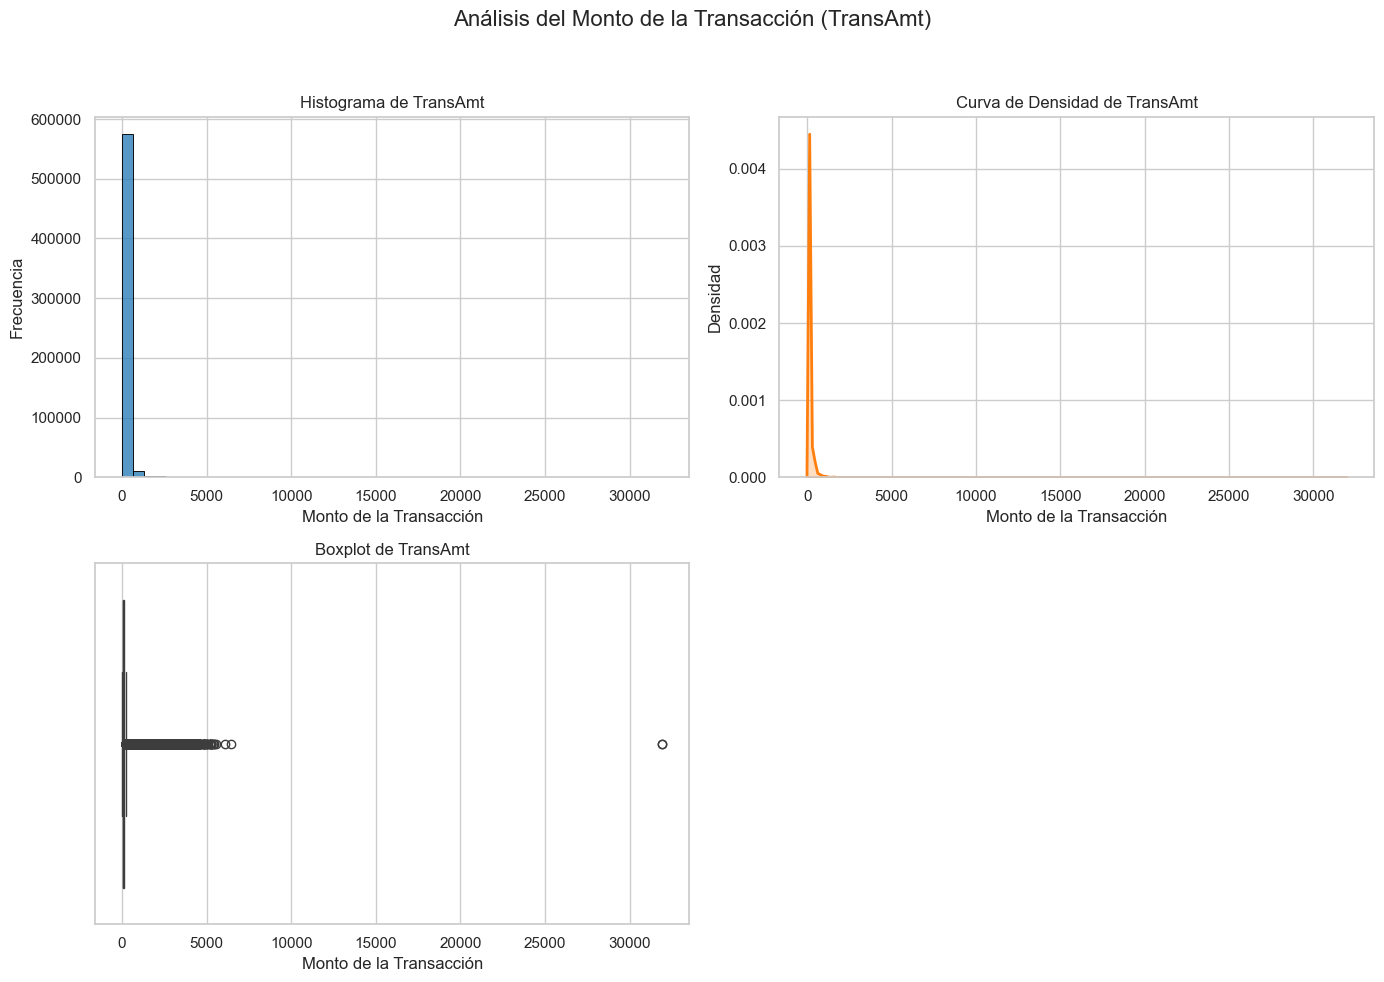

In [16]:
# Estilo general
sns.set(style="whitegrid")

# ========================
# Parte 1: TransAmt (histograma + curva de densidad + boxplot)
# ========================
fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10))
fig1.suptitle('Análisis del Monto de la Transacción (TransAmt)', fontsize=16)

# Histograma
sns.histplot(FD1['TransAmt'], bins=50, kde=False,
             color='#1f77b4', edgecolor='black', ax=axes1[0, 0])
axes1[0, 0].set_title('Histograma de TransAmt')
axes1[0, 0].set_xlabel('Monto de la Transacción')
axes1[0, 0].set_ylabel('Frecuencia')

# Curva de densidad
sns.kdeplot(FD1['TransAmt'], fill=True, color='#ff7f0e', linewidth=2, ax=axes1[0, 1])
axes1[0, 1].set_title('Curva de Densidad de TransAmt')
axes1[0, 1].set_xlabel('Monto de la Transacción')
axes1[0, 1].set_ylabel('Densidad')

# Boxplot
sns.boxplot(x=FD1['TransAmt'], color='#2ca02c', ax=axes1[1, 0])
axes1[1, 0].set_title('Boxplot de TransAmt')
axes1[1, 0].set_xlabel('Monto de la Transacción')

# Eliminar el cuarto gráfico (vacío)
fig1.delaxes(axes1[1, 1])

# Ajustar diseño
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

El análisis del monto de la transacción (`TransAmt`) se presenta a través de tres gráficos: un histograma, una curva de densidad y un boxplot. El histograma muestra una distribución altamente sesgada a la derecha, con la mayoría de las transacciones concentradas en montos bajos y muy pocas transacciones con montos extremadamente altos. La curva de densidad confirma esta observación, mostrando una densidad muy alta en montos bajos y una rápida disminución a medida que el monto aumenta. El boxplot revela la presencia de valores atípicos significativos, con algunos montos de transacción que superan los 30,000, lo que indica una gran variabilidad en los datos. En conjunto, estos gráficos destacan la naturaleza sesgada y la alta curtosis de la distribución de `TransAmt`, lo que es crucial para entender y modelar el comportamiento de las transacciones.


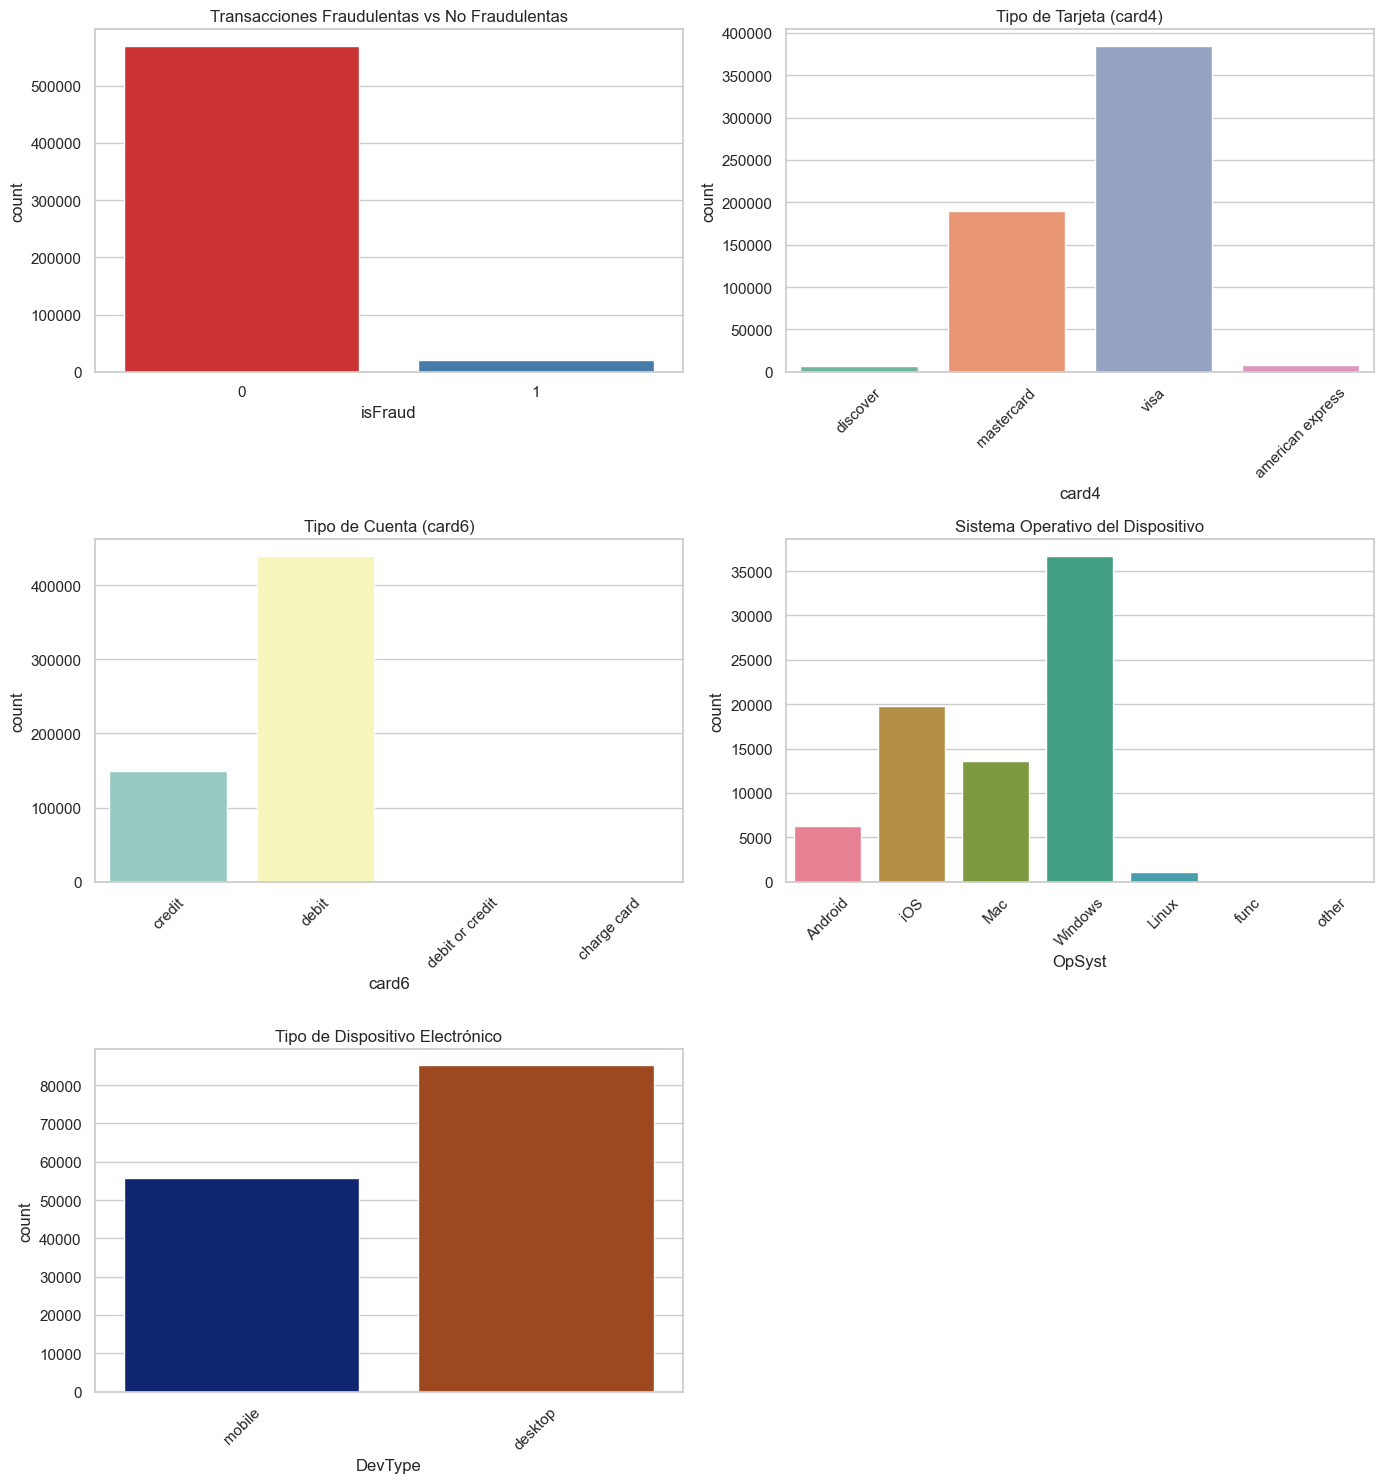


Tiempos de ejecución:
                          Descripción     Tiempo Transcurrido
0           Creación de figura y ejes  0 minutos y 0 segundos
1              Generación de gráficos  0 minutos y 4 segundos
2  Ajuste y visualización de gráficos  0 minutos y 0 segundos


In [23]:
#-------------------------------------------------------------------------
# Importar los paquetes necesarios
#-------------------------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt
import time

#-------------------------------------------------------------------------
# Estilo general
#-------------------------------------------------------------------------
sns.set(style="whitegrid")

#-------------------------------------------------------------------------
# 1. Crear figura y ejes: 3 filas x 2 columnas
#-------------------------------------------------------------------------
# Lista para almacenar los tiempos de ejecución
execution_times = []

start_time = time.time()  # Iniciar el cronómetro

fig2, axes2 = plt.subplots(3, 2, figsize=(14, 15))
axes2 = axes2.flatten()

end_time = time.time()  # Detener el cronómetro
elapsed_time = end_time - start_time
execution_times.append(("Creación de figura y ejes", elapsed_time))

#-------------------------------------------------------------------------
# 2. Generar gráficos categóricos
#-------------------------------------------------------------------------
start_time = time.time()  # Iniciar el cronómetro

# Gráfico 1: isFraud
sns.countplot(x='isFraud', data=FD1, ax=axes2[0], hue='isFraud', palette='Set1', legend=False)
axes2[0].set_title('Transacciones Fraudulentas vs No Fraudulentas')

# Gráfico 2: card4 (tipo de tarjeta)
sns.countplot(x='card4', data=FD1, ax=axes2[1], hue='card4', palette='Set2', legend=False)
axes2[1].set_title('Tipo de Tarjeta (card4)')
axes2[1].tick_params(axis='x', rotation=45)

# Gráfico 3: card6 (tipo de cuenta)
sns.countplot(x='card6', data=FD1, ax=axes2[2], hue='card6', palette='Set3', legend=False)
axes2[2].set_title('Tipo de Cuenta (card6)')
axes2[2].tick_params(axis='x', rotation=45)

# Gráfico 4: OpSyst (sistema operativo)
sns.countplot(x='OpSyst', data=FD1, ax=axes2[3], hue='OpSyst', palette='husl', legend=False)
axes2[3].set_title('Sistema Operativo del Dispositivo')
axes2[3].tick_params(axis='x', rotation=45)

# Gráfico 5: DevType (tipo de dispositivo)
sns.countplot(x='DevType', data=FD1, ax=axes2[4], hue='DevType', palette='dark', legend=False)
axes2[4].set_title('Tipo de Dispositivo Electrónico')
axes2[4].tick_params(axis='x', rotation=45)

# Eliminar el sexto gráfico (vacío)
fig2.delaxes(axes2[5])

end_time = time.time()  # Detener el cronómetro
elapsed_time = end_time - start_time
execution_times.append(("Generación de gráficos", elapsed_time))

#-------------------------------------------------------------------------
# 3. Ajustar diseño y mostrar gráficos
#-------------------------------------------------------------------------
start_time = time.time()  # Iniciar el cronómetro

plt.tight_layout()
plt.show()

end_time = time.time()  # Detener el cronómetro
elapsed_time = end_time - start_time
execution_times.append(("Ajuste y visualización de gráficos", elapsed_time))

#-------------------------------------------------------------------------
# 4. Mostrar los tiempos de ejecución en una tabla
#-------------------------------------------------------------------------
# Convertir los tiempos a minutos y segundos
formatted_times = [(desc, f"{int(t // 60)} minutos y {int(t % 60)} segundos") for desc, t in execution_times]

# Crear un DataFrame para mostrar los tiempos
times_df = pd.DataFrame(formatted_times, columns=["Descripción", "Tiempo Transcurrido"])
print("\nTiempos de ejecución:")
print(times_df)


El conjunto de gráficos proporciona una visión detallada de diversas características de las transacciones. El primer gráfico muestra una clara distinción entre transacciones fraudulentas y no fraudulentas, con una abrumadora mayoría de transacciones no fraudulentas. El segundo gráfico ilustra la distribución del tipo de tarjeta (`card4`), destacando que la mayoría de las transacciones se realizan con tarjetas Visa, seguidas por MasterCard, mientras que Discover y American Express tienen una representación mínima. El tercer gráfico presenta el tipo de cuenta (`card6`), indicando que la mayoría de las transacciones son de débito, con una cantidad significativa de crédito y muy pocas de tarjetas de carga o prepago. El cuarto gráfico muestra el sistema operativo del dispositivo (`OpSyst`), con Windows siendo el más común, seguido por iOS y Mac, mientras que Android y otros sistemas operativos tienen una menor representación. Finalmente, el quinto gráfico muestra el tipo de dispositivo electrónico (`DevType`), revelando que la mayoría de las transacciones se realizan desde dispositivos móviles, con una cantidad considerable desde dispositivos de escritorio. En conjunto, estos gráficos proporcionan una visión integral de las características de las transacciones, destacando la prevalencia de transacciones no fraudulentas, el uso predominante de tarjetas Visa y débito, y la preferencia por dispositivos móviles y sistemas operativos Windows.

C:\Users\jthow\AppData\Local\Temp\ipykernel_5420\1823331133.py:27: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=FD1, x='isFraud_label', y='TransAmt', ci=None, ax=axes[1])


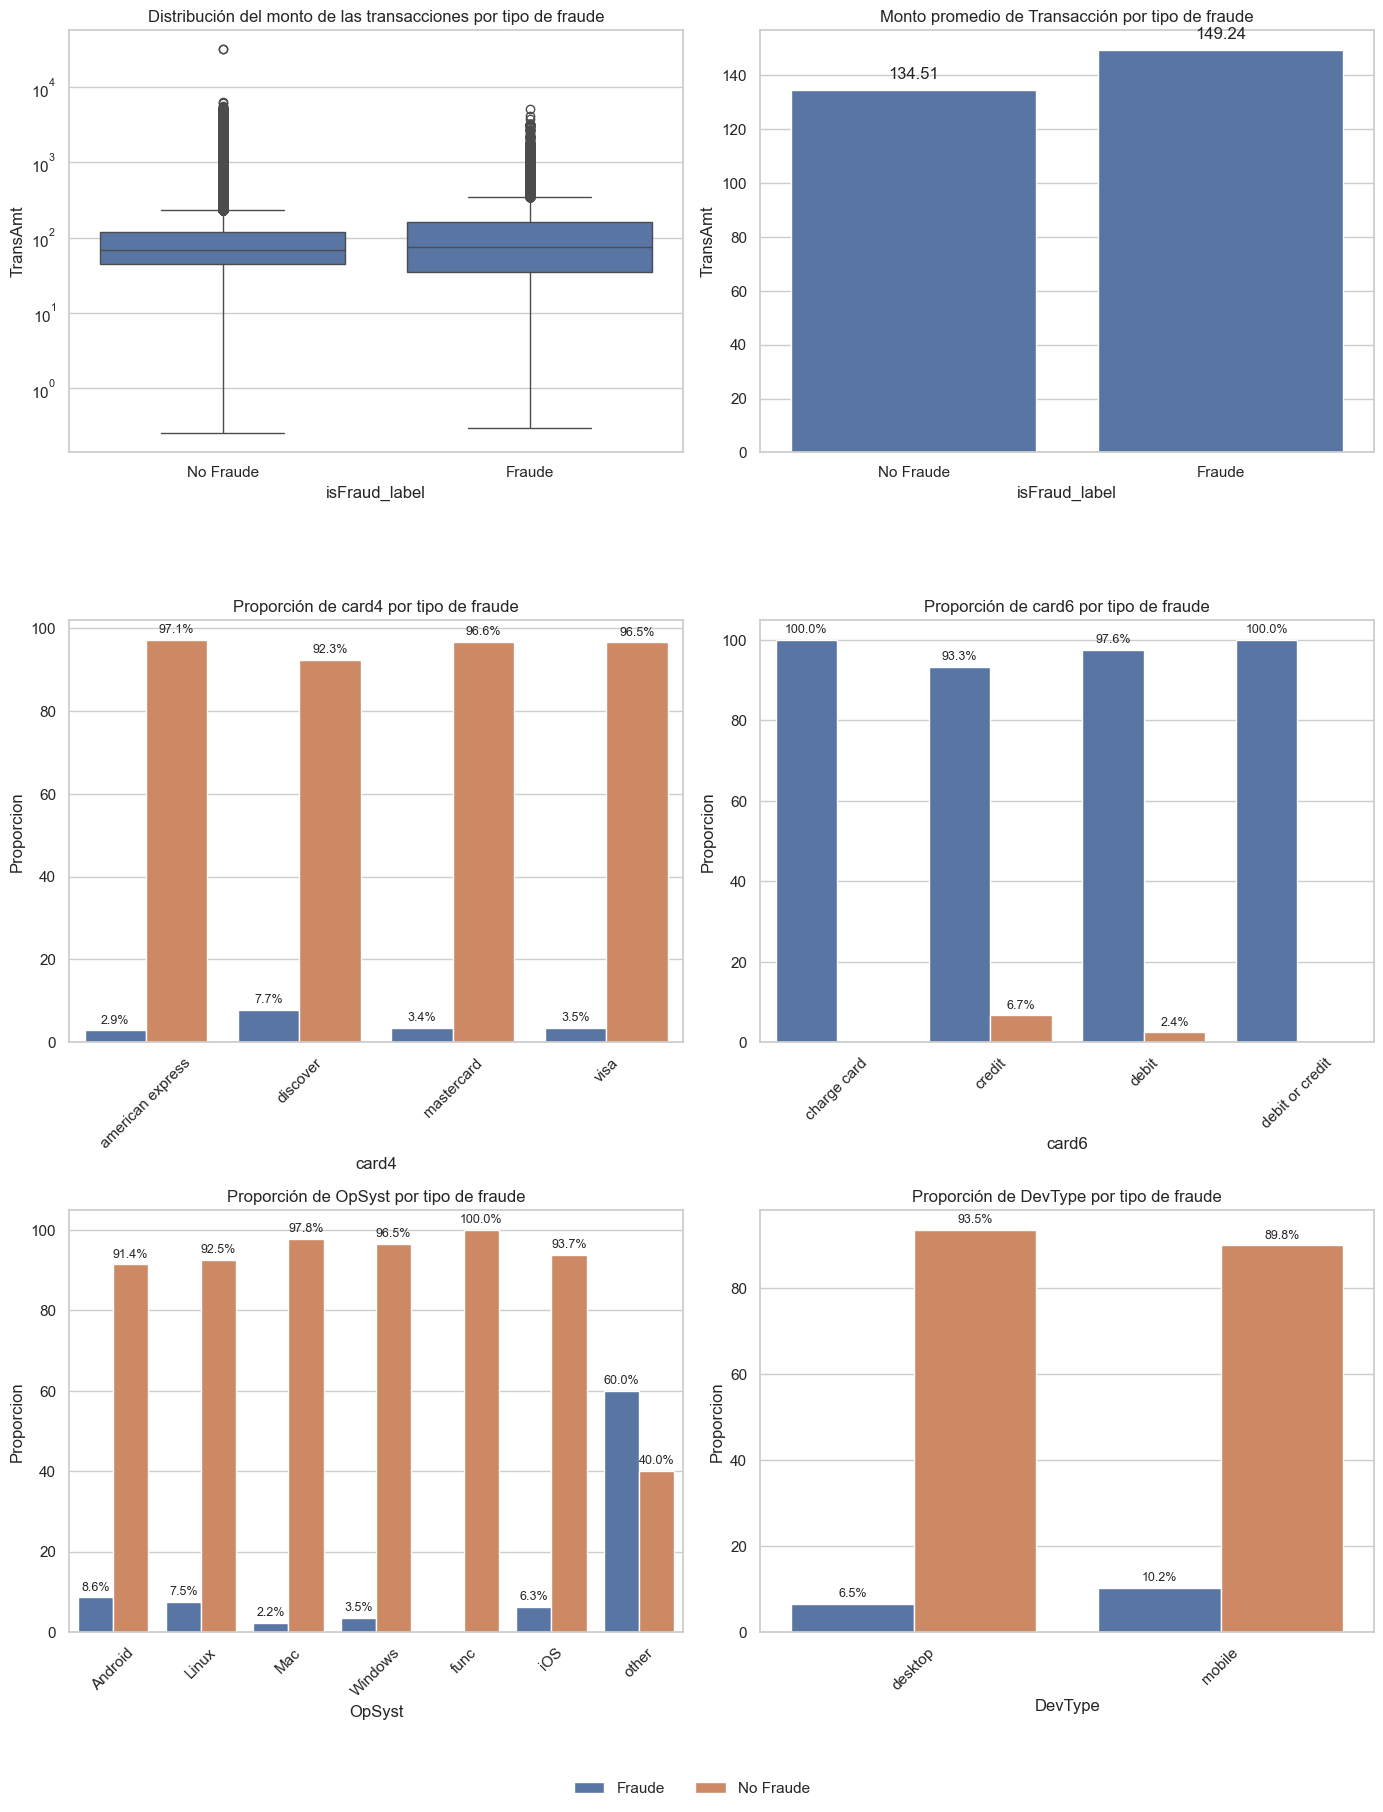

In [19]:
# Estilo general
sns.set(style="whitegrid")

# Variables categóricas y limpieza
variables = ['card4', 'card6', 'OpSyst', 'DevType']
FD1.columns = FD1.columns.str.strip()
FD1['isFraud_label'] = FD1['isFraud'].map({0: 'No Fraude', 1: 'Fraude'})

# Verificamos columnas disponibles
columnas_disponibles = FD1.columns.tolist()
variables_existentes = [v for v in variables if v in columnas_disponibles]

# Crear figura 3x2
fig, axes = plt.subplots(3, 2, figsize=(14, 18))
axes = axes.flatten()

# Guardar handles de la leyenda para usar después
handles_global = None
labels_global = None

# Gráfico 1: Boxplot - Distribución de montos
sns.boxplot(data=FD1, x='isFraud_label', y='TransAmt', ax=axes[0])
axes[0].set_title('Distribución del monto de las transacciones por tipo de fraude')
axes[0].set_yscale('log')  # Escala logarítmica para manejar valores extremos

# Gráfico 2: Barplot - Monto promedio
sns.barplot(data=FD1, x='isFraud_label', y='TransAmt', ci=None, ax=axes[1])
axes[1].set_title('Monto promedio de Transacción por tipo de fraude')

# Etiquetas sobre las barras del gráfico 2
max_y1 = axes[1].get_ylim()[1]
for p in axes[1].patches:
    height = p.get_height()
    axes[1].text(p.get_x() + p.get_width() / 2, height + 0.02 * max_y1,
                 f'{height:,.2f}', ha='center', va='bottom')

# Gráficos proporcionales
for i, var in enumerate(variables_existentes, start=2):
    counts = FD1.groupby([var, 'isFraud_label']).size().rename("conteo").reset_index()
    total = counts.groupby(var)['conteo'].transform('sum')
    counts['Proporcion'] = (counts['conteo'] / total) * 100

    ax = axes[i]
    barplot = sns.barplot(data=counts, x=var, y='Proporcion', hue='isFraud_label', ax=ax)
    ax.set_title(f'Proporción de {var} por tipo de fraude')
    ax.tick_params(axis='x', rotation=45)

    if handles_global is None:
        handles_global, labels_global = ax.get_legend_handles_labels()
    ax.get_legend().remove()

    # Etiquetas sobre las barras
    max_y = ax.get_ylim()[1]
    for p in ax.patches:
        height = p.get_height()
        if not pd.isna(height) and height > 0:
            ax.text(p.get_x() + p.get_width() / 2, height + 0.01 * max_y,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# Eliminar ejes vacíos si sobran
for j in range(len(variables_existentes) + 2, len(axes)):
    fig.delaxes(axes[j])

# Añadir leyenda global (abajo centrada)
fig.legend(handles=handles_global, labels=labels_global, loc='lower center',
           bbox_to_anchor=(0.5, -0.01), ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0.03, 1, 1])  # Espacio inferior para la leyenda
plt.show()

El conjunto de gráficos proporciona una visión detallada de las características de las transacciones en función de si son fraudulentas o no. El primer gráfico muestra la distribución del monto de las transacciones, destacando que los montos fraudulentos tienden a ser ligeramente más altos en promedio que los no fraudulentos. El segundo gráfico ilustra el monto promedio de las transacciones, mostrando que las transacciones fraudulentas tienen un monto promedio de 149.24, mientras que las no fraudulentas tienen un promedio de 134.51. Los gráficos de proporción revelan que la mayoría de las transacciones fraudulentas se realizan con tarjetas Visa y débito, mientras que las transacciones no fraudulentas están más distribuidas entre diferentes tipos de tarjetas y cuentas. Además, los sistemas operativos Windows y Mac son más comunes en transacciones no fraudulentas, mientras que Android y otros sistemas operativos tienen una mayor proporción en transacciones fraudulentas. Finalmente, los dispositivos móviles son predominantes en transacciones fraudulentas, mientras que los dispositivos de escritorio tienen una mayor proporción en transacciones no fraudulentas. En conjunto, estos gráficos destacan las diferencias en los patrones de transacciones fraudulentas y no fraudulentas, proporcionando insights valiosos para la detección de fraudes.

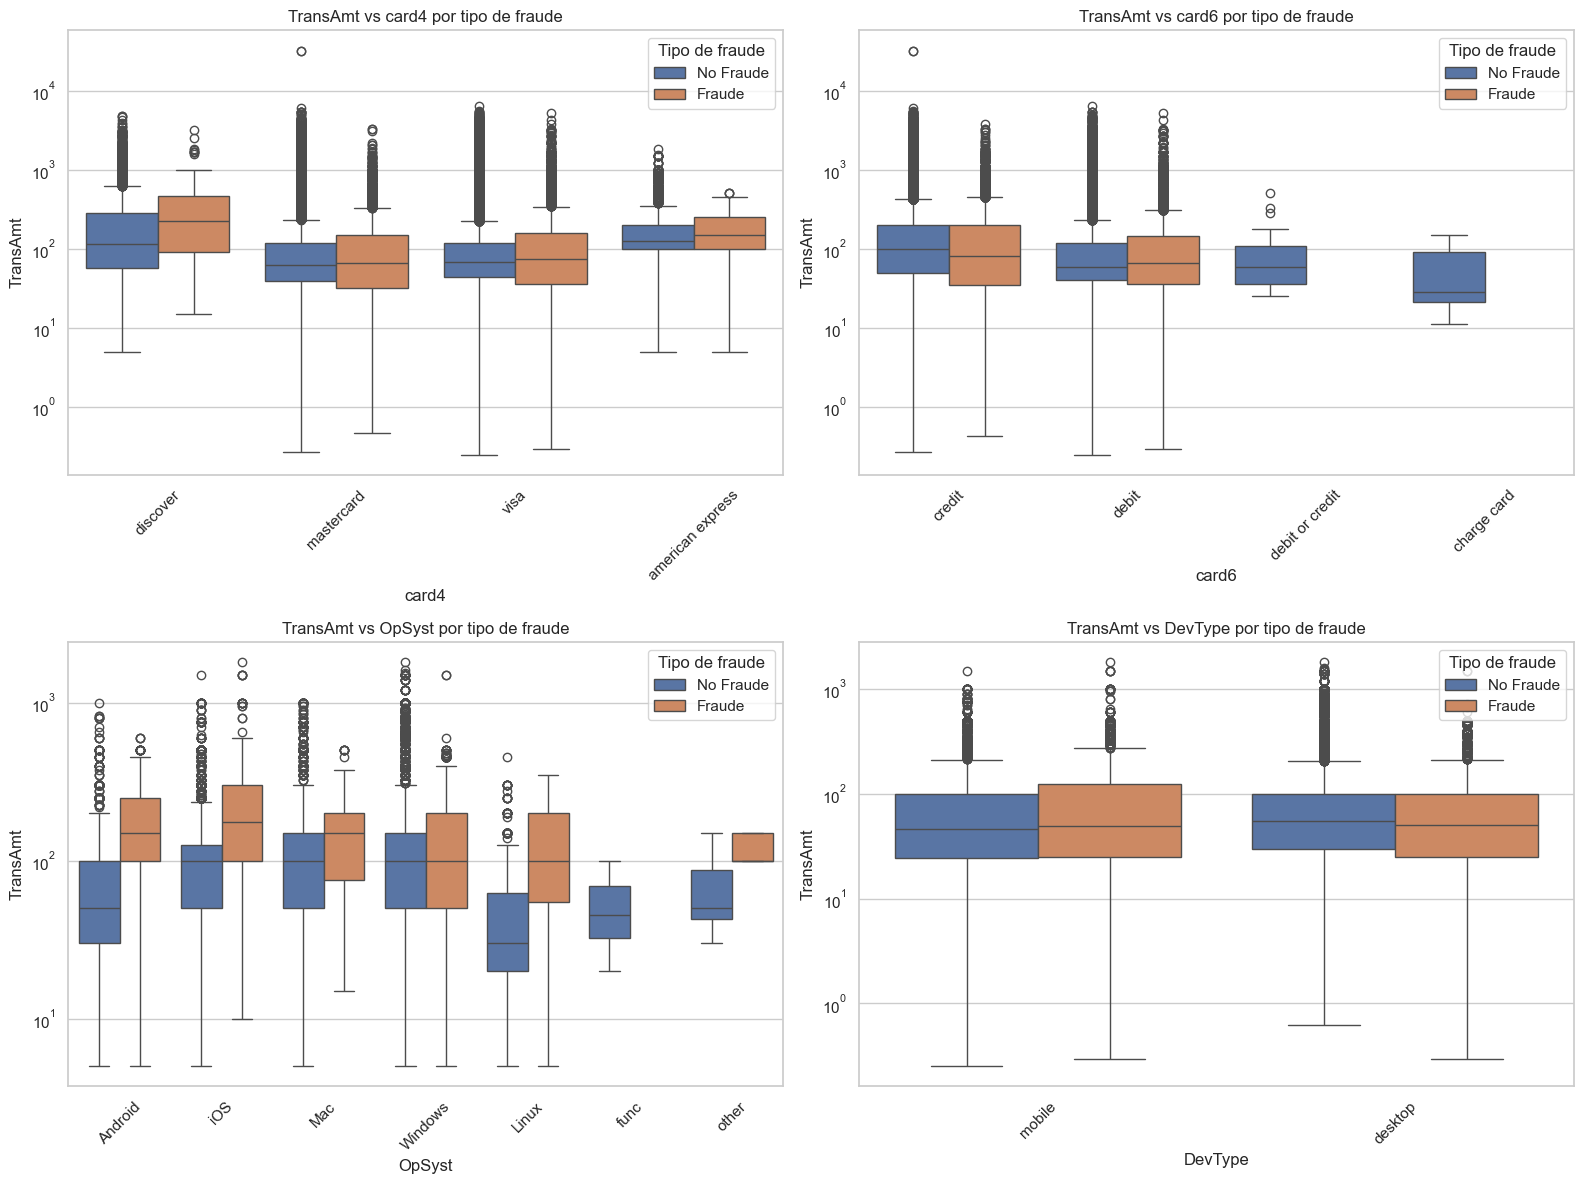

In [20]:
# Asegurar que la variable isFraud_label existe
FD1['isFraud_label'] = FD1['isFraud'].map({0: 'No Fraude', 1: 'Fraude'})

# Estilo
sns.set(style="whitegrid")

# Variables categóricas a comparar con TransAmt
variables = ['card4', 'card6', 'OpSyst', 'DevType']

# Crear figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Generar los boxplots con hue
for i, var in enumerate(variables):
    sns.boxplot(data=FD1, x=var, y='TransAmt', hue='isFraud_label', ax=axes[i])
    axes[i].set_title(f'TransAmt vs {var} por tipo de fraude')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_yscale('log')  # Escala log para valores extremos
    axes[i].legend(title='Tipo de fraude', loc='upper right')

plt.tight_layout()
plt.show()

El conjunto de gráficos presenta un análisis detallado del monto de las transacciones (`TransAmt`) en función de diversas variables y su relación con el fraude. En el primer gráfico, se observa que los montos de las transacciones fraudulentas tienden a ser ligeramente más altos que los de las transacciones no fraudulentas, independientemente del tipo de tarjeta (`card4`), aunque la variabilidad es alta en ambos casos. El segundo gráfico muestra que las transacciones fraudulentas con tarjetas de débito y crédito tienen montos similares a las no fraudulentas, pero con una mayor dispersión en los datos. El tercer gráfico ilustra que los montos de las transacciones fraudulentas varían significativamente entre diferentes sistemas operativos (`OpSyst`), con Android y Windows mostrando una mayor variabilidad. Finalmente, el cuarto gráfico indica que los montos de las transacciones fraudulentas son generalmente más altos en dispositivos móviles en comparación con dispositivos de escritorio. En conjunto, estos gráficos destacan que las transacciones fraudulentas tienden a involucrar montos más altos y muestran una mayor variabilidad en diferentes contextos, proporcionando insights valiosos para la detección y prevención de fraudes.